Epoch 1/50


/tmp/ipython-input-1279598425.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7851 - loss: 0.6500 - val_accuracy: 0.7821 - val_loss: 0.6079
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7716 - loss: 0.6062 - val_accuracy: 0.7821 - val_loss: 0.5593
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7733 - loss: 0.5612 - val_accuracy: 0.7877 - val_loss: 0.5150
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7671 - loss: 0.5229 - val_accuracy: 0.7877 - val_loss: 0.4823
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7779 - loss: 0.4888 - val_accuracy: 0.7877 - val_loss: 0.4621
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7711 - loss: 0.4856 - val_accuracy: 0.7821 - val_loss: 0.4509
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7904 - loss: 0.4599 - val_accuracy: 0.7821 - val_loss: 0.4428
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7841 - loss: 0.4494 - val_accuracy: 0.7821 - val_loss: 0.4387
Ep

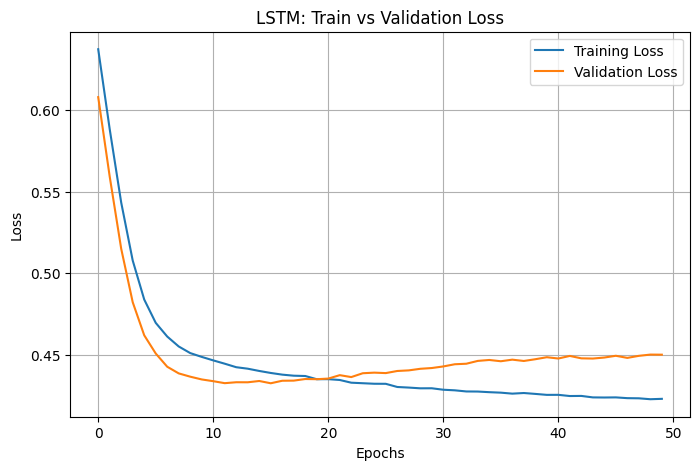

LSTM Model Accuracy: 0.8156


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

data = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Sex'] = LabelEncoder().fit_transform(data['Sex'])
X = data[['Pclass', 'Sex', 'Age', 'Fare']].values
y = data['Survived'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.reshape(X.shape[0], 1, X.shape[1])
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
model = Sequential()
model.add(LSTM(32, activation='tanh', input_shape=(1, X.shape[2])))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val), verbose=1)
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM: Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"LSTM Model Accuracy: {accuracy:.4f}")